<a href="https://colab.research.google.com/github/matteogolfarelli/DataCentricAI/blob/main/Scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [159]:
import pandas as pd
from sklearn.datasets import load_iris

In [160]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Now, I will drop the sepal length and sepal width features.

In [161]:
df = df.drop(columns=['sepal length (cm)', 'sepal width (cm)'])

df.describe()

,petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000
mean,3.758000,1.199333,1.000000
std,1.765298,0.762238,0.819232
min,1.000000,0.100000,0.000000
25%,1.600000,0.300000,0.000000
50%,4.350000,1.300000,1.000000
75%,5.100000,1.800000,2.000000
max,6.900000,2.500000,2.000000


### Applying MinMaxScaler

**MinMaxScaler** scales and translates each feature individually such that it is in the given range on the training set, e.g., between zero and one. This scaling is typically done by subtracting the minimum value and dividing by the range (max - min).

In [162]:
from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()
scaled_features_minmax = scaler_minmax.fit_transform(df[['petal length (cm)', 'petal width (cm)']])

df_minmax = df.copy()
df_minmax['petal length (cm)'] = scaled_features_minmax[:, 0]
df_minmax['petal width (cm)'] = scaled_features_minmax[:, 1]

display(df_minmax.head())

,petal length (cm),petal width (cm),target
0,0.067797,0.041667,0
1,0.067797,0.041667,0
2,0.050847,0.041667,0
3,0.084746,0.041667,0
4,0.067797,0.041667,0


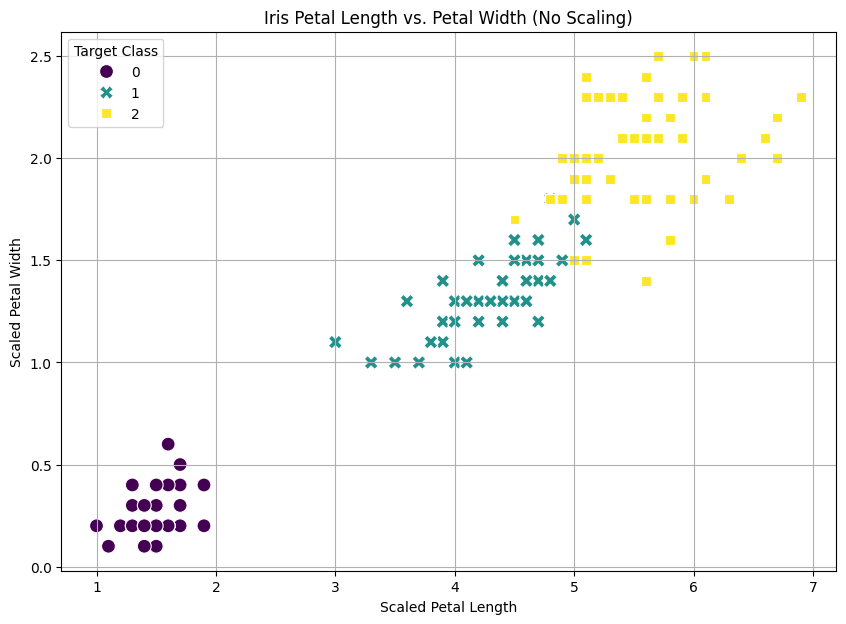

In [163]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='petal length (cm)',
    y='petal width (cm)',
    hue='target',
    style='target',
    data=df,
    palette='viridis',
    s=100
)
plt.title('Iris Petal Length vs. Petal Width (No Scaling)')
plt.xlabel('Scaled Petal Length')
plt.ylabel('Scaled Petal Width')
plt.legend(title='Target Class')
plt.grid(True)
plt.show()

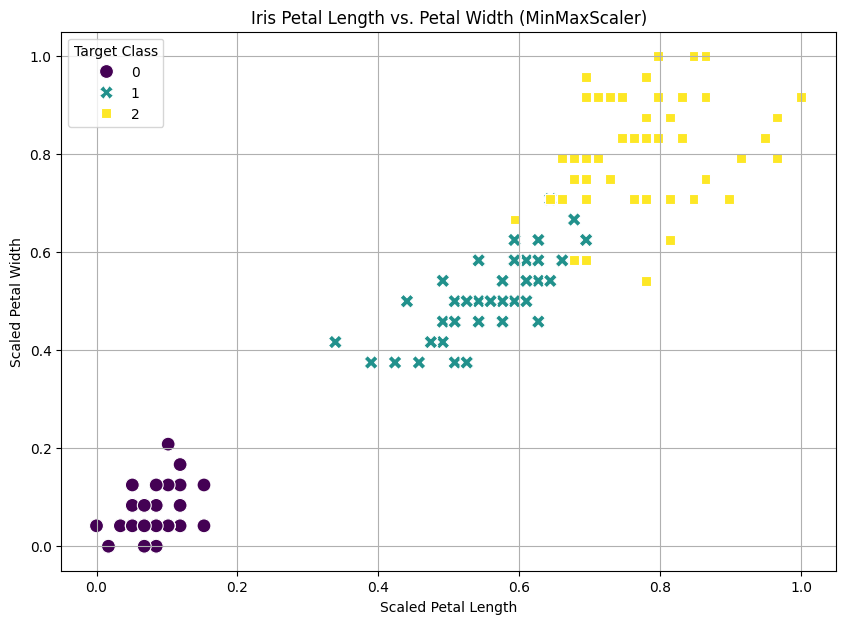

In [164]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='petal length (cm)',
    y='petal width (cm)',
    hue='target',
    style='target',
    data=df_minmax,
    palette='viridis',
    s=100
)
plt.title('Iris Petal Length vs. Petal Width (MinMaxScaler)')
plt.xlabel('Scaled Petal Length')
plt.ylabel('Scaled Petal Width')
plt.legend(title='Target Class')
plt.grid(True)
plt.show()

### Applying RobustScaler

**RobustScaler** scales features using statistics that are robust to outliers. It removes the median and scales the data according to the quantile range (the IQR - interquartile range). The IQR is the range between the 1st quartile (25th percentile) and the 3rd quartile (75th percentile).

In [165]:
from sklearn.preprocessing import RobustScaler

scaler_robust = RobustScaler()
scaled_features_robust = scaler_robust.fit_transform(df[['petal length (cm)', 'petal width (cm)']])

df_robust = df.copy()
df_robust['petal length (cm)'] = scaled_features_robust[:, 0]
df_robust['petal width (cm)'] = scaled_features_robust[:, 1]

display(df_robust.head())

,petal length (cm),petal width (cm),target
0,-0.842857,-0.733333,0
1,-0.842857,-0.733333,0
2,-0.871429,-0.733333,0
3,-0.814286,-0.733333,0
4,-0.842857,-0.733333,0


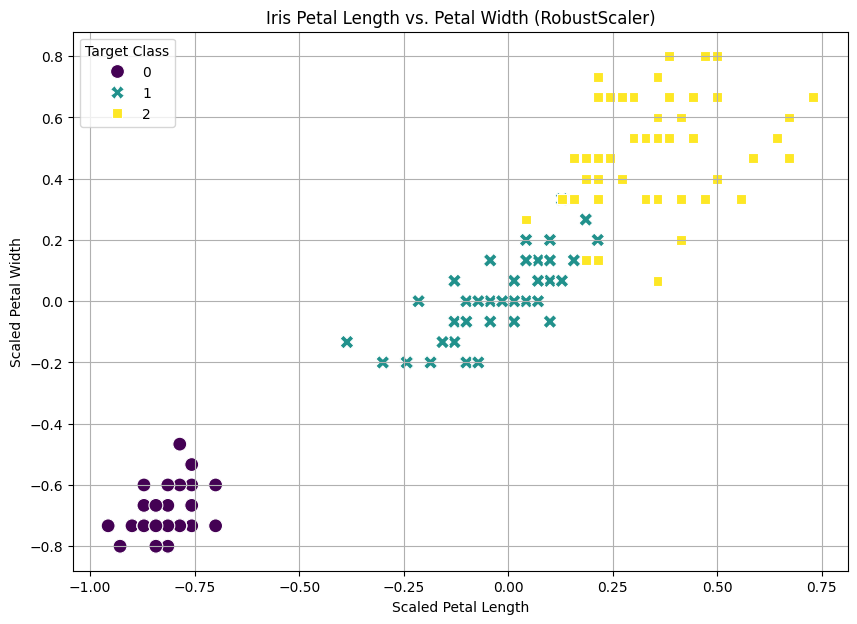

In [166]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='petal length (cm)',
    y='petal width (cm)',
    hue='target',
    style='target',
    data=df_robust,
    palette='viridis',
    s=100
)
plt.title('Iris Petal Length vs. Petal Width (RobustScaler)')
plt.xlabel('Scaled Petal Length')
plt.ylabel('Scaled Petal Width')
plt.legend(title='Target Class')
plt.grid(True)
plt.show()

### Applying StandardScaler

**StandardScaler** standardizes features by removing the mean and scaling to unit variance. The standard score of a sample `x` is calculated as: `z = (x - u) / s`, where `u` is the mean of the training samples or zero if `with_mean=False`, and `s` is the standard deviation of the training samples or one if `with_std=False`.

In [167]:
from sklearn.preprocessing import StandardScaler

scaler_standard = StandardScaler()
scaled_features_standard = scaler_standard.fit_transform(df[['petal length (cm)', 'petal width (cm)']])

df_standard = df.copy()
df_standard['petal length (cm)'] = scaled_features_standard[:, 0]
df_standard['petal width (cm)'] = scaled_features_standard[:, 1]

display(df_standard.head())

,petal length (cm),petal width (cm),target
0,-1.340227,-1.315444,0
1,-1.340227,-1.315444,0
2,-1.397064,-1.315444,0
3,-1.283389,-1.315444,0
4,-1.340227,-1.315444,0


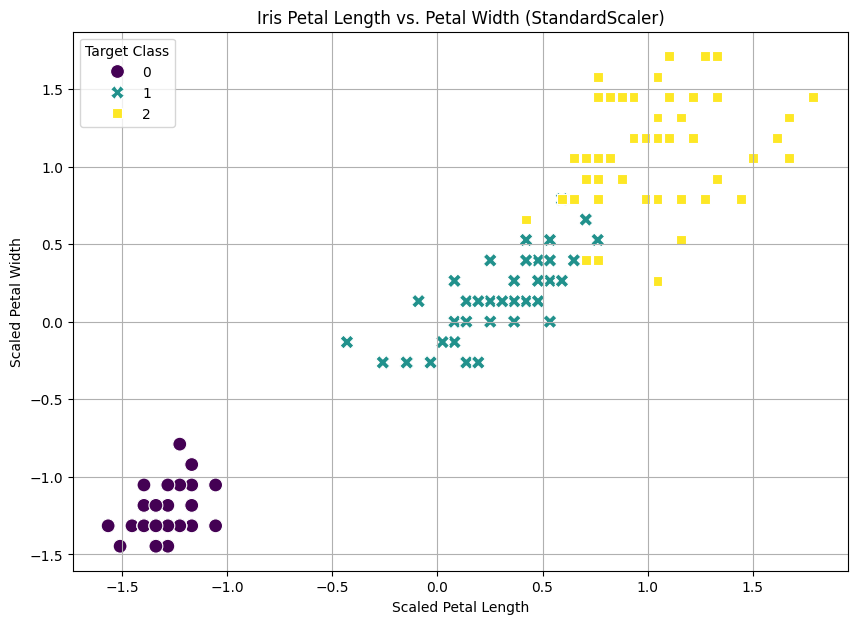

In [168]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='petal length (cm)',
    y='petal width (cm)',
    hue='target',
    style='target',
    data=df_standard,
    palette='viridis',
    s=100
)
plt.title('Iris Petal Length vs. Petal Width (StandardScaler)')
plt.xlabel('Scaled Petal Length')
plt.ylabel('Scaled Petal Width')
plt.legend(title='Target Class')
plt.grid(True)
plt.show()

What does it happen if we add an outlier?

In [169]:
#new_outlier = pd.DataFrame([[30.0, 30.0, 2]], columns=['petal length (cm)', 'petal width (cm)', 'target'])
#df = pd.concat([df, new_outlier], ignore_index=True)

#print('DataFrame after adding outlier:')
#display(df.tail())

### Reapplying MinMaxScaler with Outlier

Let's re-apply the MinMaxScaler to the `df` which now includes the outlier. This will show how MinMaxScaler is affected by extreme values, as it scales data to a fixed range (usually 0 to 1) using the minimum and maximum values present in the data.

In [170]:
from sklearn.preprocessing import MinMaxScaler

scaler_minmax_outlier = MinMaxScaler()
scaled_features_minmax_outlier = scaler_minmax_outlier.fit_transform(df[['petal length (cm)', 'petal width (cm)']])

df_minmax_outlier = df.copy()
df_minmax_outlier['petal length (cm)'] = scaled_features_minmax_outlier[:, 0]
df_minmax_outlier['petal width (cm)'] = scaled_features_minmax_outlier[:, 1]

print('MinMaxScaler applied to data with outlier:')
display(df_minmax_outlier.head())
display(df_minmax_outlier.tail())

MinMaxScaler applied to data with outlier:


,petal length (cm),petal width (cm),target
0,0.067797,0.041667,0
1,0.067797,0.041667,0
2,0.050847,0.041667,0
3,0.084746,0.041667,0
4,0.067797,0.041667,0


,petal length (cm),petal width (cm),target
145,0.711864,0.916667,2
146,0.677966,0.750000,2
147,0.711864,0.791667,2
148,0.745763,0.916667,2
149,0.694915,0.708333,2


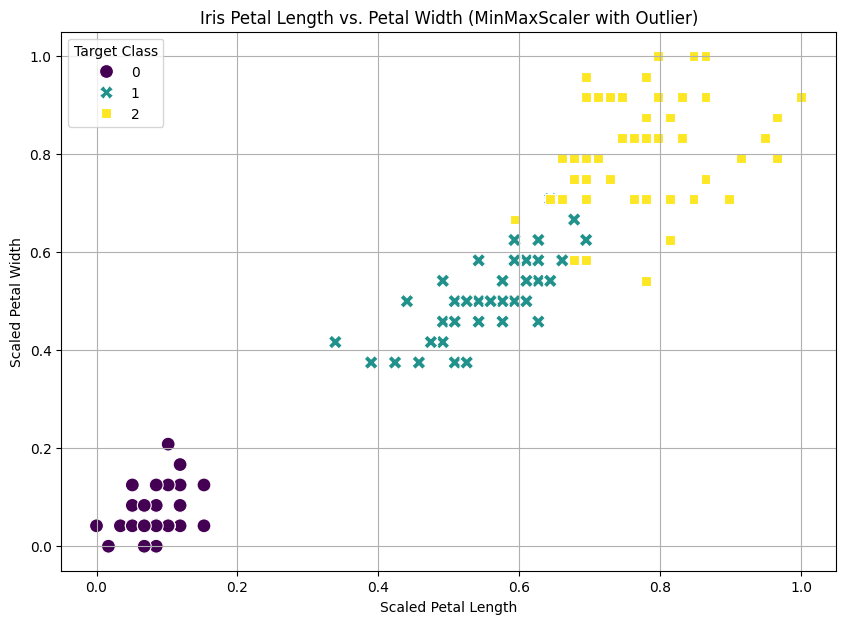

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='petal length (cm)',
    y='petal width (cm)',
    hue='target',
    style='target',
    data=df_minmax_outlier,
    palette='viridis',
    s=100
)
plt.title('Iris Petal Length vs. Petal Width (MinMaxScaler with Outlier)')
plt.xlabel('Scaled Petal Length')
plt.ylabel('Scaled Petal Width')
plt.legend(title='Target Class')
plt.grid(True)
plt.show()

### Reapplying RobustScaler with Outlier

Next, we'll re-apply the **RobustScaler** to the dataset including the outlier. RobustScaler uses the median and interquartile range (IQR) for scaling, making it more robust to outliers compared to MinMaxScaler or StandardScaler.

In [172]:
from sklearn.preprocessing import RobustScaler

scaler_robust_outlier = RobustScaler()
scaled_features_robust_outlier = scaler_robust_outlier.fit_transform(df[['petal length (cm)', 'petal width (cm)']])

df_robust_outlier = df.copy()
df_robust_outlier['petal length (cm)'] = scaled_features_robust_outlier[:, 0]
df_robust_outlier['petal width (cm)'] = scaled_features_robust_outlier[:, 1]

print('RobustScaler applied to data with outlier:')
display(df_robust_outlier.head())
display(df_robust_outlier.tail())

RobustScaler applied to data with outlier:


,petal length (cm),petal width (cm),target
0,-0.842857,-0.733333,0
1,-0.842857,-0.733333,0
2,-0.871429,-0.733333,0
3,-0.814286,-0.733333,0
4,-0.842857,-0.733333,0


,petal length (cm),petal width (cm),target
145,0.242857,0.666667,2
146,0.185714,0.400000,2
147,0.242857,0.466667,2
148,0.300000,0.666667,2
149,0.214286,0.333333,2


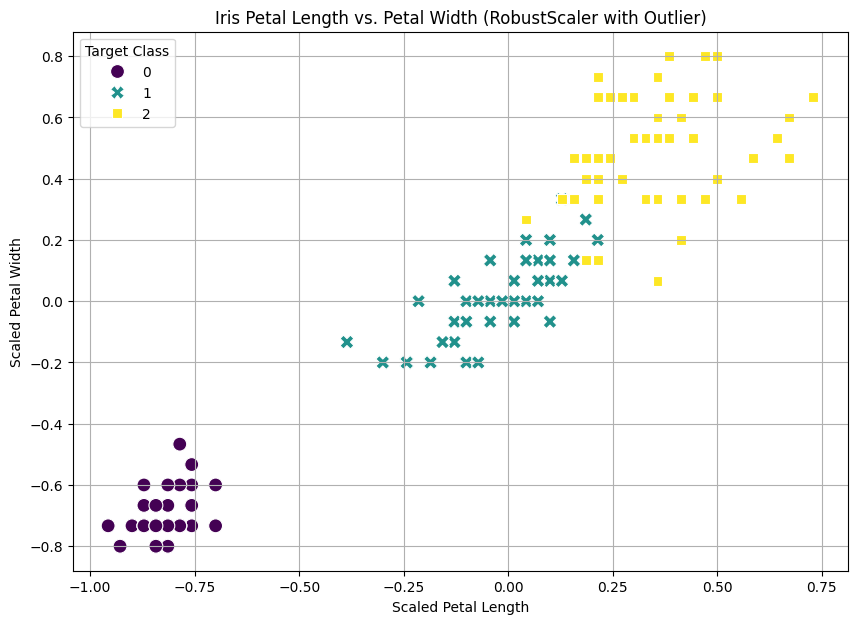

In [173]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='petal length (cm)',
    y='petal width (cm)',
    hue='target',
    style='target',
    data=df_robust_outlier,
    palette='viridis',
    s=100
)
plt.title('Iris Petal Length vs. Petal Width (RobustScaler with Outlier)')
plt.xlabel('Scaled Petal Length')
plt.ylabel('Scaled Petal Width')
plt.legend(title='Target Class')
plt.grid(True)
plt.show()

### Reapplying StandardScaler with Outlier

Finally, let's re-apply the **StandardScaler** to the dataset containing the outlier. StandardScaler scales data to have a mean of 0 and a standard deviation of 1. It is sensitive to outliers, as both the mean and standard deviation are influenced by extreme values.

In [174]:
from sklearn.preprocessing import StandardScaler

scaler_standard_outlier = StandardScaler()
scaled_features_standard_outlier = scaler_standard_outlier.fit_transform(df[['petal length (cm)', 'petal width (cm)']])

df_standard_outlier = df.copy()
df_standard_outlier['petal length (cm)'] = scaled_features_standard_outlier[:, 0]
df_standard_outlier['petal width (cm)'] = scaled_features_standard_outlier[:, 1]

print('StandardScaler applied to data with outlier:')
display(df_standard_outlier.head())
display(df_standard_outlier.tail())

StandardScaler applied to data with outlier:


,petal length (cm),petal width (cm),target
0,-1.340227,-1.315444,0
1,-1.340227,-1.315444,0
2,-1.397064,-1.315444,0
3,-1.283389,-1.315444,0
4,-1.340227,-1.315444,0


,petal length (cm),petal width (cm),target
145,0.819596,1.448832,2
146,0.705921,0.922303,2
147,0.819596,1.053935,2
148,0.933271,1.448832,2
149,0.762758,0.790671,2


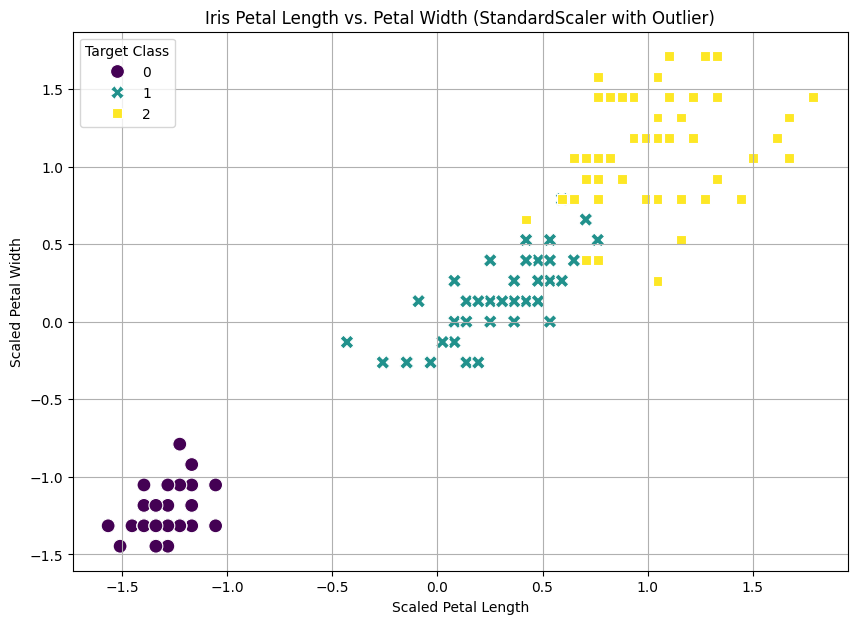

In [175]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='petal length (cm)',
    y='petal width (cm)',
    hue='target',
    style='target',
    data=df_standard_outlier,
    palette='viridis',
    s=100
)
plt.title('Iris Petal Length vs. Petal Width (StandardScaler with Outlier)')
plt.xlabel('Scaled Petal Length')
plt.ylabel('Scaled Petal Width')
plt.legend(title='Target Class')
plt.grid(True)
plt.show()

## Applying K-Means Clustering

Now, let's apply K-Means clustering to `df` (original data with outlier) and `df_minmax` (MinMaxScaler data without outlier) using `k=3` to see how the scaling and outlier affect the clustering results.

### K-Means Clustering on Original `df` (with outlier)

In [176]:
from sklearn.cluster import KMeans

kmeans_df = KMeans(n_clusters=3, random_state=42, n_init=10) # n_init is set to 10 to suppress warning
df_petal_features = df[['petal length (cm)', 'petal width (cm)']]
df['kmeans_cluster'] = kmeans_df.fit_predict(df_petal_features)

print('K-Means clustering on original df (with outlier):')
display(df.head())
display(df.tail())

K-Means clustering on original df (with outlier):


,petal length (cm),petal width (cm),target,kmeans_cluster
0,1.4,0.2,0,1
1,1.4,0.2,0,1
2,1.3,0.2,0,1
3,1.5,0.2,0,1
4,1.4,0.2,0,1


,petal length (cm),petal width (cm),target,kmeans_cluster
145,5.2,2.3,2,0
146,5.0,1.9,2,0
147,5.2,2.0,2,0
148,5.4,2.3,2,0
149,5.1,1.8,2,0


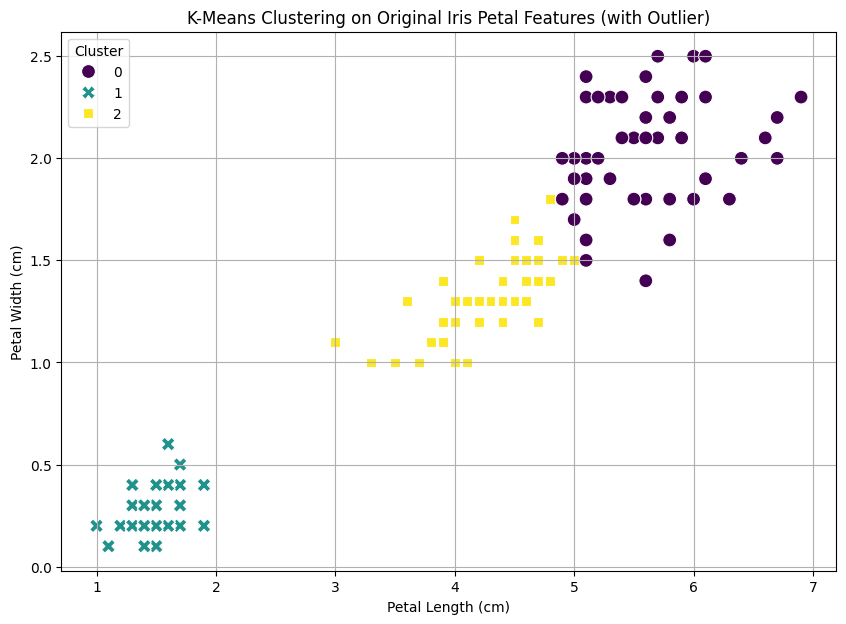

In [177]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='petal length (cm)',
    y='petal width (cm)',
    hue='kmeans_cluster',
    style='kmeans_cluster',
    data=df,
    palette='viridis',
    s=100
)
plt.title('K-Means Clustering on Original Iris Petal Features (with Outlier)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

### K-Means Clustering on `df_minmax` (without outlier)

In [178]:
kmeans_df_minmax = KMeans(n_clusters=3, random_state=42, n_init=10) # n_init is set to 10 to suppress warning
df_minmax_petal_features = df_minmax[['petal length (cm)', 'petal width (cm)']]
df_minmax['kmeans_cluster'] = kmeans_df_minmax.fit_predict(df_minmax_petal_features)

print('K-Means clustering on df_minmax (without outlier):')
display(df_minmax.head())
display(df_minmax.tail())

K-Means clustering on df_minmax (without outlier):


,petal length (cm),petal width (cm),target,kmeans_cluster
0,0.067797,0.041667,0,1
1,0.067797,0.041667,0,1
2,0.050847,0.041667,0,1
3,0.084746,0.041667,0,1
4,0.067797,0.041667,0,1


,petal length (cm),petal width (cm),target,kmeans_cluster
145,0.711864,0.916667,2,0
146,0.677966,0.750000,2,0
147,0.711864,0.791667,2,0
148,0.745763,0.916667,2,0
149,0.694915,0.708333,2,0


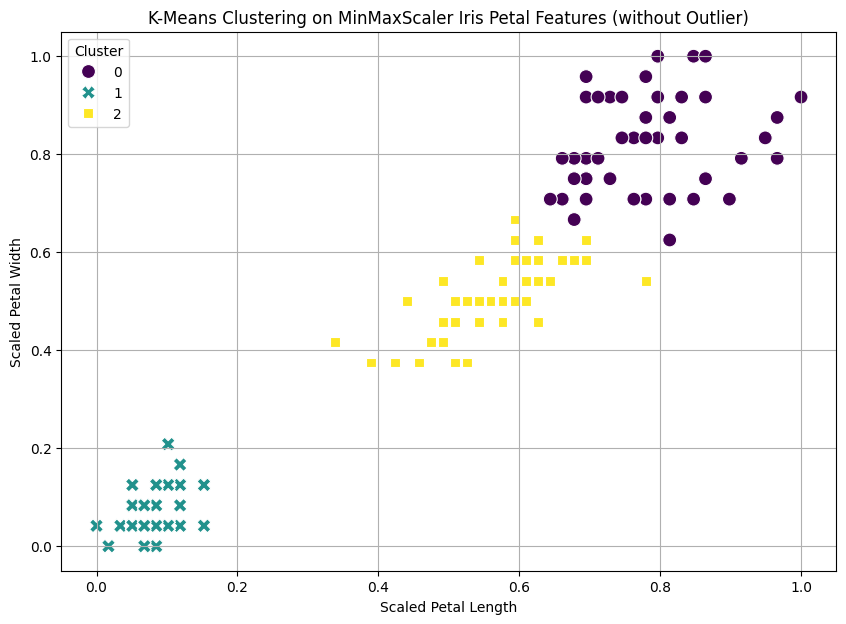

In [179]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='petal length (cm)',
    y='petal width (cm)',
    hue='kmeans_cluster',
    style='kmeans_cluster',
    data=df_minmax,
    palette='viridis',
    s=100
)
plt.title('K-Means Clustering on MinMaxScaler Iris Petal Features (without Outlier)')
plt.xlabel('Scaled Petal Length')
plt.ylabel('Scaled Petal Width')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

## Load Bank Data CSV Dataset

I will now load the bank data from the provided GitHub CSV URL into a pandas DataFrame.

In [5]:
import requests
import pandas as pd
import io

# URL of the CSV file
csv_url = 'https://raw.githubusercontent.com/matteogolfarelli/DataCentricAI/main/Data%20Understanding/bank_data.csv'

# Download the file content
response = requests.get(csv_url)
response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

# Load CSV data from the content into a pandas DataFrame
bank_df_csv = pd.read_csv(io.StringIO(response.text))

print('Bank Data CSV loaded successfully. Displaying the first 5 rows:')
display(bank_df_csv.head())

Bank Data CSV loaded successfully. Displaying the first 5 rows:


,id,age,sex,region,income,married,children,car,save_act,current_act,mortgage,pep
0,ID12101,48.0,FEMALE,INNER_CITY,17546.0,NO,1.0,NO,NO,NO,NO,YES
1,ID12102,40.0,MALE,TOWN,30085.1,YES,3.0,YES,NO,YES,YES,NO
2,ID12103,51.0,FEMALE,INNER_CITY,16575.4,YES,0.0,YES,YES,YES,NO,NO
3,ID12104,23.0,FEMALE,TOWN,20375.4,YES,3.0,NO,NO,YES,NO,NO
4,ID12105,57.0,FEMALE,RURAL,50576.3,YES,0.0,NO,YES,NO,NO,NO


## Scatterplot of Age vs. Income

Let's visualize the distribution of `age` against `income` in the `bank_df_csv` dataset.

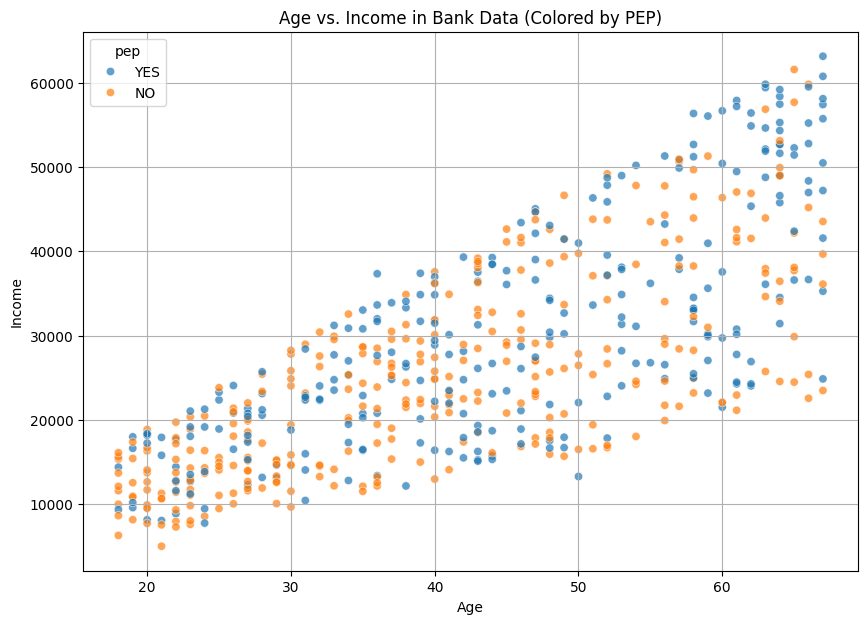

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='age',
    y='income',
    hue='pep',
    data=bank_df_csv,
    alpha=0.7 # Add transparency for better visualization of overlapping points
)

plt.title('Age vs. Income in Bank Data (Colored by PEP)')
plt.xlabel('Age')
plt.ylabel('Income')
plt.grid(True)
plt.show()

## Apply MinMaxScaler to Numerical Features of Bank Data

I will now apply `MinMaxScaler` to the numerical columns of the `bank_df_csv` dataset to scale them to a range between 0 and 1.

In [9]:
from sklearn.preprocessing import MinMaxScaler

# Identify numerical columns
numerical_cols = bank_df_csv.select_dtypes(include=['number']).columns

# Initialize MinMaxScaler
scaler_bank_minmax = MinMaxScaler()

# Apply MinMaxScaler to numerical columns
bank_df_scaled_minmax_numerical = scaler_bank_minmax.fit_transform(bank_df_csv[numerical_cols])

# Create a new DataFrame with scaled numerical features
bank_df_minmax = bank_df_csv.copy()
bank_df_minmax[numerical_cols] = bank_df_scaled_minmax_numerical

print('Bank Data after MinMaxScaler application (numerical columns scaled):')
display(bank_df_minmax.head())

Bank Data after MinMaxScaler application (numerical columns scaled):


,id,age,sex,region,income,married,children,car,save_act,current_act,mortgage,pep
0,ID12101,0.612245,FEMALE,INNER_CITY,0.215634,NO,0.333333,NO,NO,NO,NO,YES
1,ID12102,0.448980,MALE,TOWN,0.431395,YES,1.000000,YES,NO,YES,YES,NO
2,ID12103,0.673469,FEMALE,INNER_CITY,0.198933,YES,0.000000,YES,YES,YES,NO,NO
3,ID12104,0.102041,FEMALE,TOWN,0.264320,YES,1.000000,NO,NO,YES,NO,NO
4,ID12105,0.795918,FEMALE,RURAL,0.783987,YES,0.000000,NO,YES,NO,NO,NO


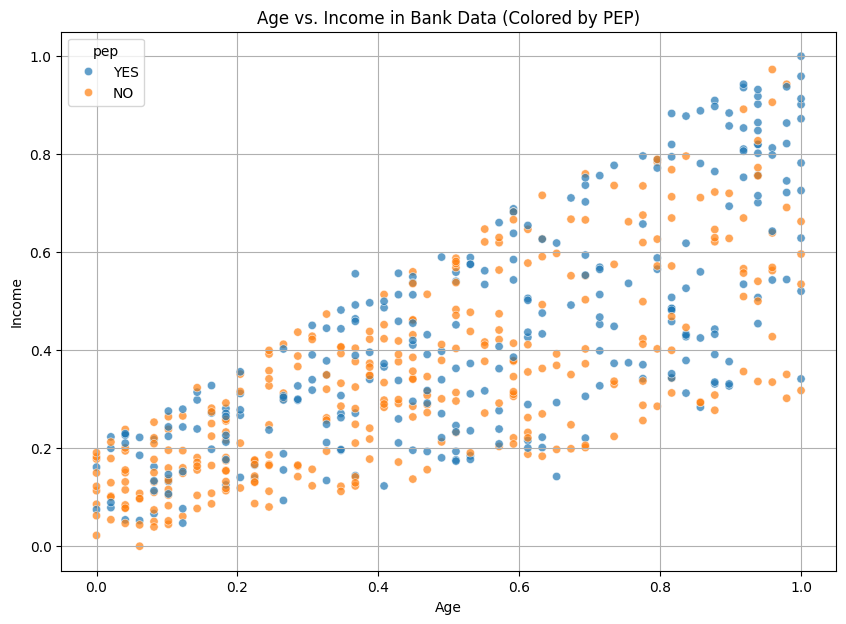

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='age',
    y='income',
    hue='pep',
    data=bank_df_minmax,
    alpha=0.7 # Add transparency for better visualization of overlapping points
)

plt.title('Age vs. Income in Bank Data (Colored by PEP)')
plt.xlabel('Age')
plt.ylabel('Income')
plt.grid(True)
plt.show()

## K-Means Clustering on `bank_df_csv` (k=4)

I will now apply K-Means clustering with 4 clusters to the numerical features of the original `bank_df_csv` dataset and visualize the results based on 'age' and 'income'.

In [16]:
from sklearn.cluster import KMeans

# Select only 'age' and 'income' columns for clustering from bank_df_csv
numerical_features_bank_csv = ['age', 'income']

kmeans_bank_csv = KMeans(n_clusters=4, random_state=42, n_init=10)
bank_df_csv['kmeans_cluster'] = kmeans_bank_csv.fit_predict(bank_df_csv[numerical_features_bank_csv])

print('K-Means clustering on bank_df_csv (k=4) using only age and income:')
display(bank_df_csv.head())

K-Means clustering on bank_df_csv (k=4) using only age and income:


,id,age,sex,region,income,married,children,car,save_act,current_act,mortgage,pep,kmeans_cluster
0,ID12101,48.0,FEMALE,INNER_CITY,17546.0,NO,1.0,NO,NO,NO,NO,YES,2
1,ID12102,40.0,MALE,TOWN,30085.1,YES,3.0,YES,NO,YES,YES,NO,0
2,ID12103,51.0,FEMALE,INNER_CITY,16575.4,YES,0.0,YES,YES,YES,NO,NO,2
3,ID12104,23.0,FEMALE,TOWN,20375.4,YES,3.0,NO,NO,YES,NO,NO,0
4,ID12105,57.0,FEMALE,RURAL,50576.3,YES,0.0,NO,YES,NO,NO,NO,3


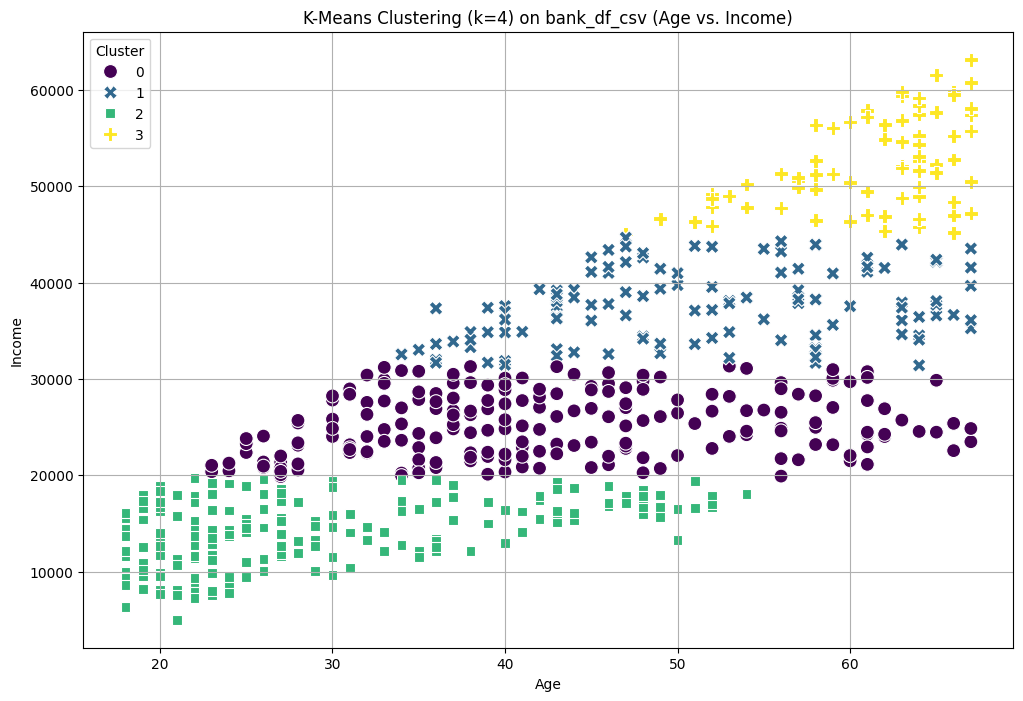

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='age',
    y='income',
    hue='kmeans_cluster',
    style='kmeans_cluster',
    data=bank_df_csv,
    palette='viridis',
    s=100
)
plt.title('K-Means Clustering (k=4) on bank_df_csv (Age vs. Income)')
plt.xlabel('Age')
plt.ylabel('Income')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

## K-Means Clustering on `bank_df_minmax` (k=4)

Next, I will apply K-Means clustering with 4 clusters to the scaled numerical features of the `bank_df_minmax` dataset and visualize the results based on 'age' and 'income'. This will show the effect of scaling on clustering.

In [19]:
from sklearn.cluster import KMeans

# Select only 'age' and 'income' columns for clustering from bank_df_minmax (already scaled)
numerical_features_bank_minmax = ['age', 'income']

kmeans_bank_minmax = KMeans(n_clusters=4, random_state=42, n_init=10)
bank_df_minmax['kmeans_cluster'] = kmeans_bank_minmax.fit_predict(bank_df_minmax[numerical_features_bank_minmax])

print('K-Means clustering on bank_df_minmax (k=4) using only age and income:')
display(bank_df_minmax.head())

K-Means clustering on bank_df_minmax (k=4) using only age and income:


,id,age,sex,region,income,married,children,car,save_act,current_act,mortgage,pep,kmeans_cluster
0,ID12101,0.612245,FEMALE,INNER_CITY,0.215634,NO,0.333333,NO,NO,NO,NO,YES,3
1,ID12102,0.448980,MALE,TOWN,0.431395,YES,1.000000,YES,NO,YES,YES,NO,3
2,ID12103,0.673469,FEMALE,INNER_CITY,0.198933,YES,0.000000,YES,YES,YES,NO,NO,3
3,ID12104,0.102041,FEMALE,TOWN,0.264320,YES,1.000000,NO,NO,YES,NO,NO,1
4,ID12105,0.795918,FEMALE,RURAL,0.783987,YES,0.000000,NO,YES,NO,NO,NO,2


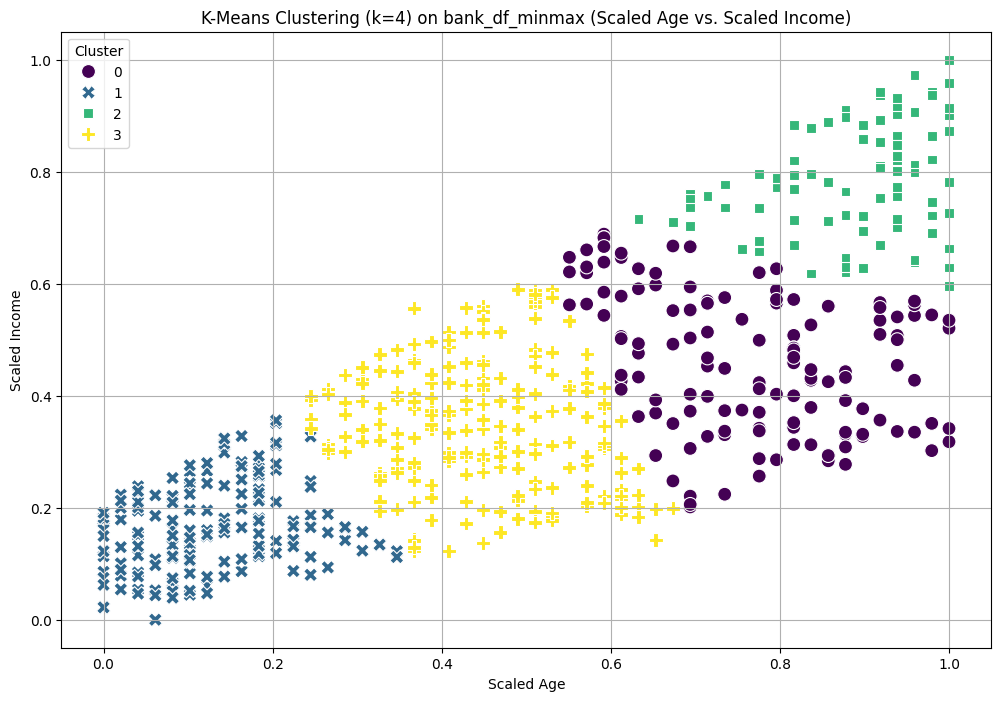

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='age',
    y='income',
    hue='kmeans_cluster',
    style='kmeans_cluster',
    data=bank_df_minmax,
    palette='viridis',
    s=100
)
plt.title('K-Means Clustering (k=4) on bank_df_minmax (Scaled Age vs. Scaled Income)')
plt.xlabel('Scaled Age')
plt.ylabel('Scaled Income')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()